In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [4]:
from unsloth import FastLanguageModel
from huggingface_hub import hf_hub_download
from peft import set_peft_model_state_dict
def load_adapter(repo):
   model,tokenizer=FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        load_in_4bit=True,
        max_seq_length=2048,
   )
   model=FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
   try:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.safetensors"
        )
   except:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.bin"
        )
   from safetensors.torch import load_file
   state_dict=load_file(model_weights)
   set_peft_model_state_dict(model,state_dict)
   return model
    

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [5]:
adapter_reasoning=load_adapter("3-adapter-merge-qwen-3-0.6B-reasoning-openmath-10k")

==((====))==  Unsloth 2026.6.7: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.7 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [6]:
adapter_non_reasoning=load_adapter("3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-10k")

==((====))==  Unsloth 2026.6.7: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [7]:
adapter_ag_news=load_adapter("3-adapter-merge-qwen-3-0.6B-ag-news-10k")

==((====))==  Unsloth 2026.6.7: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [34]:
import torch

def extract_all_deltas(model):
    deltas = {}
    n_blocks = len(model.base_model.model.model.layers)
    
    for i in range(n_blocks):
        block = model.base_model.model.model.layers[i]
        
        for name, module in block.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                try:
                    A = module.lora_A.default.weight.detach().float()
                    B = module.lora_B.default.weight.detach().float()
                    scale = module.scaling.get("default", 1.0)
                    delta_W = scale * (B @ A)
                    deltas[f"layer_{i}.{name}"] = delta_W  # flat key
                except Exception as e:
                    print(f"Block {i} | {name} | error: {e}")
    
    return deltas
                
        

In [37]:
non_reasoning_deltas=extract_all_deltas(adapter_non_reasoning)

In [38]:
ag_deltas=extract_all_deltas(adapter_ag_news)

In [35]:
reasoning_deltas=extract_all_deltas(adapter_reasoning)

In [49]:
len(reasoning_deltas)

196

In [51]:
for key,val in reasoning_deltas.items():
    print(key)
    print(val)
    break

layer_0.self_attn.q_proj
tensor([[-5.2203e-05, -2.1545e-04,  6.4476e-04,  ..., -7.3651e-05,
         -9.4865e-04, -1.5099e-04],
        [-1.4353e-04,  1.3140e-04,  9.2272e-04,  ...,  1.7081e-04,
         -9.9068e-04, -9.3042e-05],
        [-1.2554e-04,  3.2174e-04,  6.6335e-05,  ...,  2.2857e-04,
          1.8582e-05, -4.1664e-05],
        ...,
        [-2.1948e-04,  4.2429e-04,  2.7411e-04,  ...,  3.6354e-04,
         -4.5546e-04, -2.3990e-04],
        [ 2.5362e-05,  1.1997e-04,  3.2696e-04,  ...,  1.1112e-04,
         -2.8915e-04, -1.1027e-04],
        [-9.4403e-05, -1.6146e-04,  3.6087e-04,  ..., -3.3645e-04,
         -2.9141e-04,  1.0008e-04]], device='cuda:0')


In [50]:
# Check first item
key, val = list(reasoning_deltas.items())[0]
print(key)
print(type(val))
print(val)

layer_0.self_attn.q_proj
<class 'torch.Tensor'>
tensor([[-5.2203e-05, -2.1545e-04,  6.4476e-04,  ..., -7.3651e-05,
         -9.4865e-04, -1.5099e-04],
        [-1.4353e-04,  1.3140e-04,  9.2272e-04,  ...,  1.7081e-04,
         -9.9068e-04, -9.3042e-05],
        [-1.2554e-04,  3.2174e-04,  6.6335e-05,  ...,  2.2857e-04,
          1.8582e-05, -4.1664e-05],
        ...,
        [-2.1948e-04,  4.2429e-04,  2.7411e-04,  ...,  3.6354e-04,
         -4.5546e-04, -2.3990e-04],
        [ 2.5362e-05,  1.1997e-04,  3.2696e-04,  ...,  1.1112e-04,
         -2.8915e-04, -1.1027e-04],
        [-9.4403e-05, -1.6146e-04,  3.6087e-04,  ..., -3.3645e-04,
         -2.9141e-04,  1.0008e-04]], device='cuda:0')


In [52]:
!git clone https://github.com/SrishtikSekar/Lora_Adapter_Merging.git

Cloning into 'Lora_Adapter_Merging'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 80 (delta 30), reused 59 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 2.20 MiB | 8.43 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [41]:
!ls


huggingface_tokenizers_cache  Lora_Adapter_Merging  unsloth_compiled_cache


In [42]:
%cd Lora_Adapter_Merging

/kaggle/working/Lora_Adapter_Merging


In [43]:
!ls

docs			load_adapter.py      README.md
extract_lora_deltas.py	model_evaluation.py  train_adapter.py
frobenius_norm.py	notebooks	     train_adapter_using_responses.py


In [46]:
!git pull origin main

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 297 bytes | 297.00 KiB/s, done.
From https://github.com/SrishtikSekar/Lora_Adapter_Merging
 * branch            main       -> FETCH_HEAD
   4c89ae1..b53b6a4  main       -> origin/main
Updating 4c89ae1..b53b6a4
Fast-forward
 frobenius_norm.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


# Model Comparision

## 1) Frobenius Norm

In [53]:
from frobenius_norm import frobenius_norm


In [ ]:
def frobenius_norm(deltas):
    model_norms={}
    for layer_name,delta in deltas.items():
        model_norms[layer_name]=delta.norm(p="fro").item()
    import matplotlib.pyplot as plt

    layers=list(model_norms.keys())
    values=list(model_norms.values())

    plt.figure(figsize=(14,6))
    plt.plot(range(len(values)),values)
    plt.xticks(range(len(values)),layers,rotation=90)
    plt.ylabel("Frobenius Norm")
    plt.xlabel("Layer")
    plt.title("Layer wise LoRA Update Strength")
    plt.tight_layout()
    plt.show()


### 1.1) Reasoning model

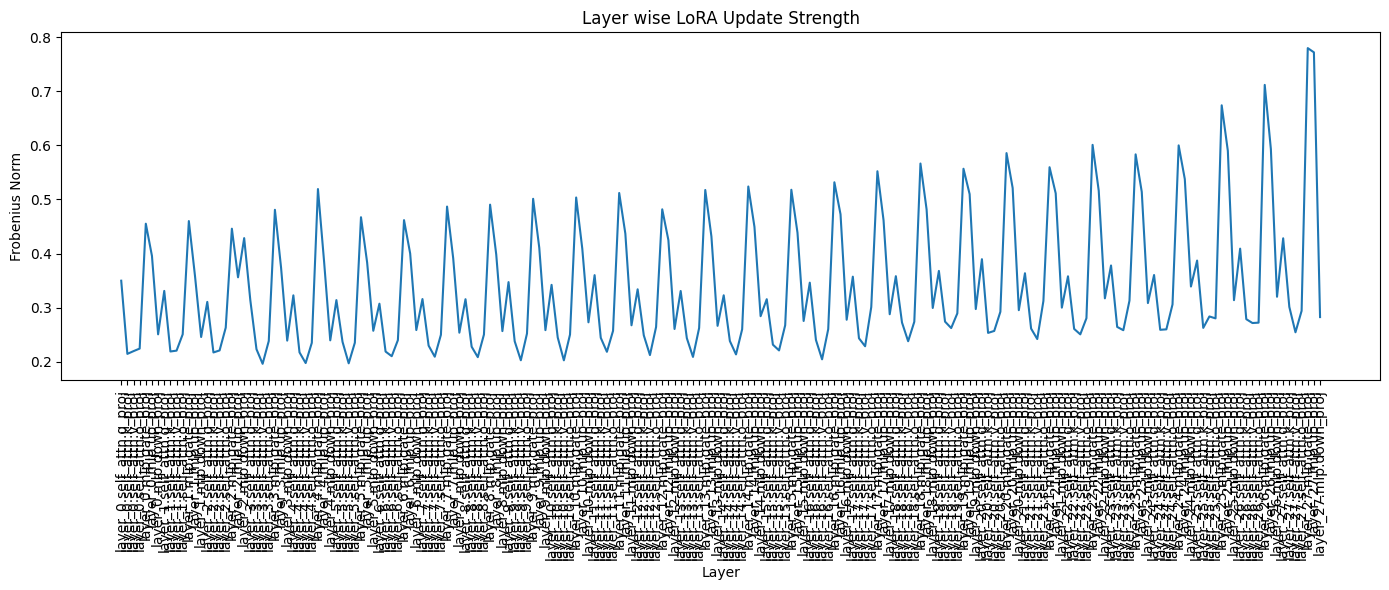

In [56]:
frobenius_norm(reasoning_deltas)

### 1.2) Non-reasoning model

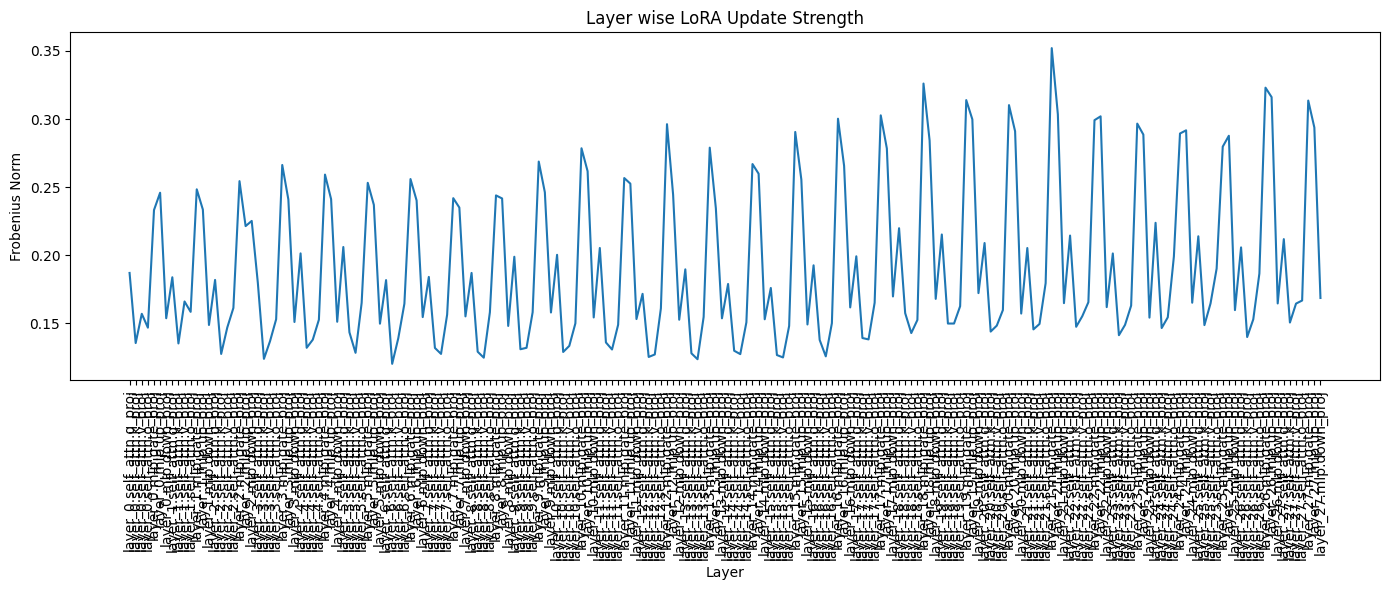

In [57]:
frobenius_norm(non_reasoning_deltas)

### 1.3) AG-News model

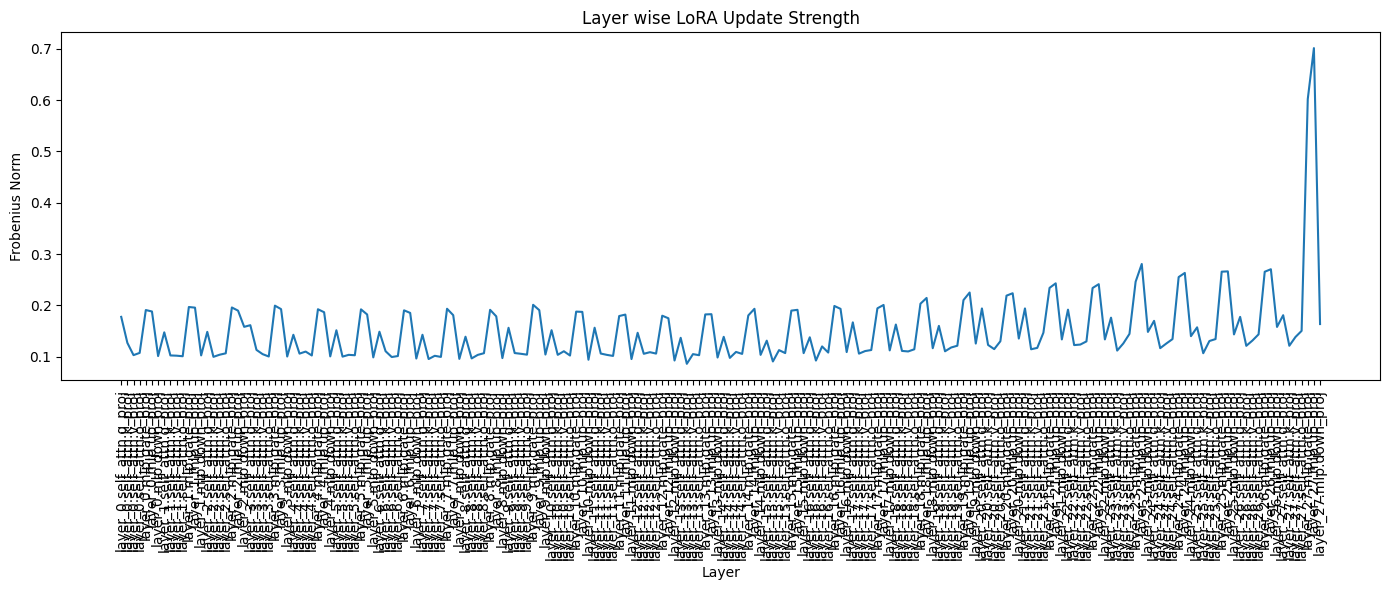

In [59]:
frobenius_norm(ag_deltas)

## 2) Cosine Similarity

In [60]:
import torch
import pandas as pd

import torch
import pandas as pd


def true_cosine_similarity(delta1, delta2):

    v1 = delta1.flatten().to(torch.float64)
    v2 = delta2.flatten().to(torch.float64)

    dot_product = torch.dot(v1, v2)

    norm1 = torch.norm(v1)
    norm2 = torch.norm(v2)

    cosine = dot_product / (norm1 * norm2)

    return cosine.item()


def compute_all_layer_cosines(adapter1_deltas, adapter2_deltas):

    results = []

    common_layers = set(adapter1_deltas.keys()) & set(adapter2_deltas.keys())

    for layer_name in sorted(common_layers):

        delta1 = adapter1_deltas[layer_name]
        delta2 = adapter2_deltas[layer_name]

        cosine = true_cosine_similarity(delta1, delta2)

        results.append({
            "layer": layer_name,
            "cosine_similarity": cosine
        })

    return pd.DataFrame(results)


# Compute similarities
cosine_df1 = compute_all_layer_cosines(
    reasoning_deltas,
    non_reasoning_deltas,
)
cosine_df2=compute_all_layer_cosines(
    reasoning_deltas,
    ag_deltas,
)
cosine_df3=compute_all_layer_cosines(
    non_reasoning_deltas,
    ag_deltas
)



### 2.1) Comparision between non reasoning and reasoning

In [61]:
print(cosine_df1.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.053283
    layer_0.mlp.gate_proj           0.040756
      layer_0.mlp.up_proj           0.078038
 layer_0.self_attn.k_proj           0.069615
 layer_0.self_attn.o_proj           0.073411
 layer_0.self_attn.q_proj           0.076243
 layer_0.self_attn.v_proj           0.144116
    layer_1.mlp.down_proj           0.064751
    layer_1.mlp.gate_proj           0.068127
      layer_1.mlp.up_proj           0.159478
 layer_1.self_attn.k_proj           0.080392
 layer_1.self_attn.o_proj           0.091536
 layer_1.self_attn.q_proj           0.071634
 layer_1.self_attn.v_proj           0.225097
   layer_10.mlp.down_proj           0.080190
   layer_10.mlp.gate_proj           0.066391
     layer_10.mlp.up_proj           0.102175
layer_10.self_attn.k_proj           0.132329
layer_10.self_attn.o_proj           0.072575
layer_10.self_attn.q_proj           0.142092
layer_10.self_attn.v_proj           0.254852
   layer_1

### 2.2) Comparision between reasoning and ag-news

In [62]:
print(cosine_df2.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.001885
    layer_0.mlp.gate_proj           0.008527
      layer_0.mlp.up_proj          -0.001825
 layer_0.self_attn.k_proj           0.002551
 layer_0.self_attn.o_proj           0.001524
 layer_0.self_attn.q_proj           0.021968
 layer_0.self_attn.v_proj          -0.003838
    layer_1.mlp.down_proj           0.002991
    layer_1.mlp.gate_proj           0.006611
      layer_1.mlp.up_proj           0.023472
 layer_1.self_attn.k_proj           0.012061
 layer_1.self_attn.o_proj           0.002117
 layer_1.self_attn.q_proj           0.017582
 layer_1.self_attn.v_proj           0.034978
   layer_10.mlp.down_proj          -0.007395
   layer_10.mlp.gate_proj          -0.001368
     layer_10.mlp.up_proj           0.000726
layer_10.self_attn.k_proj          -0.001291
layer_10.self_attn.o_proj           0.006295
layer_10.self_attn.q_proj           0.025430
layer_10.self_attn.v_proj           0.013560
   layer_1

### 2.3) Comparision between non reasoning and ag-news

In [63]:
print(cosine_df3.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.084841
    layer_0.mlp.gate_proj           0.034407
      layer_0.mlp.up_proj           0.046572
 layer_0.self_attn.k_proj           0.085807
 layer_0.self_attn.o_proj           0.048246
 layer_0.self_attn.q_proj           0.043682
 layer_0.self_attn.v_proj           0.076755
    layer_1.mlp.down_proj           0.054797
    layer_1.mlp.gate_proj           0.025582
      layer_1.mlp.up_proj           0.065912
 layer_1.self_attn.k_proj           0.031519
 layer_1.self_attn.o_proj           0.041706
 layer_1.self_attn.q_proj          -0.004246
 layer_1.self_attn.v_proj           0.072176
   layer_10.mlp.down_proj           0.023226
   layer_10.mlp.gate_proj           0.006648
     layer_10.mlp.up_proj           0.024081
layer_10.self_attn.k_proj           0.042292
layer_10.self_attn.o_proj           0.023058
layer_10.self_attn.q_proj           0.070489
layer_10.self_attn.v_proj           0.055386
   layer_1

## 3) Singular Values

In [72]:

import numpy as np
import torch
import matplotlib.pyplot as plt
def singular_values(deltas):
    layer_name=list(deltas.keys())[30]
    svals1 = torch.linalg.svdvals(deltas[layer_name]).cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.plot(svals1)
    plt.xlabel("Singular Value Index")
    plt.ylabel("Magnitude")
    plt.title(f"Singular Spectrum: {layer_name}")
    plt.show()


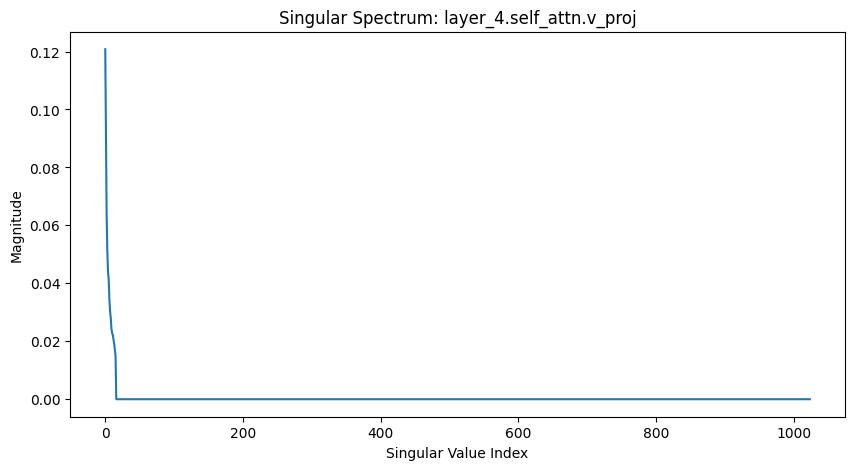

In [73]:
singular_values(reasoning_deltas)

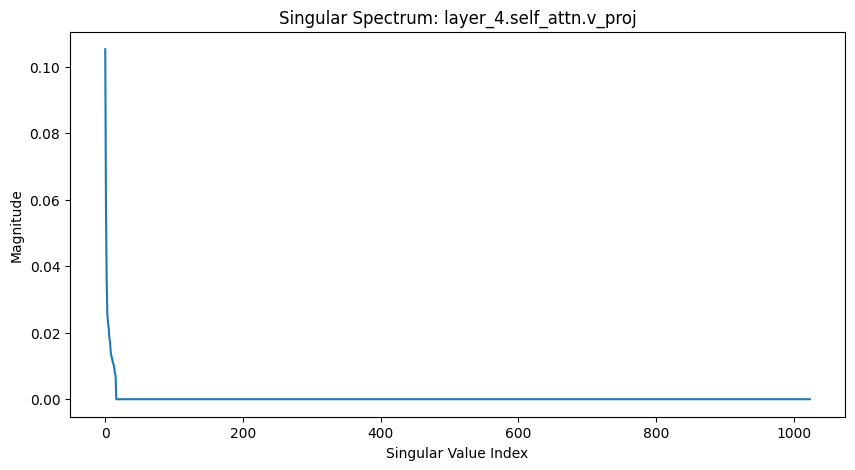

In [74]:
singular_values(non_reasoning_deltas)

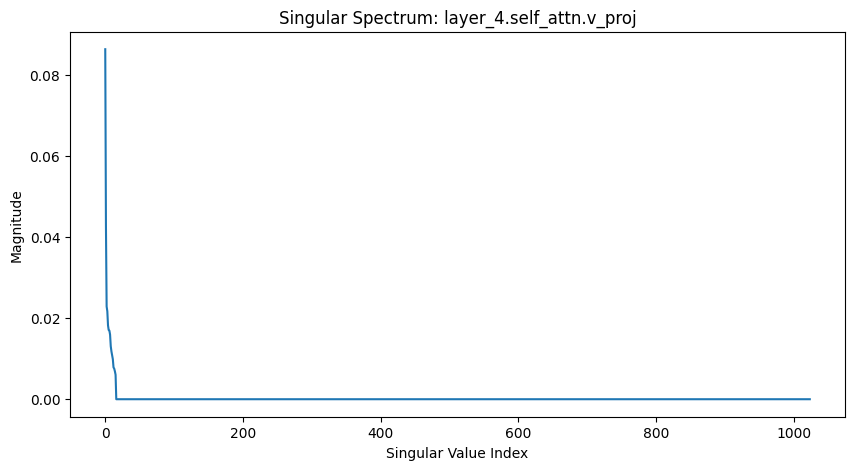

In [75]:
singular_values(ag_deltas)